# PHOENIX spectrum classification: a simple UVB example

This notebook shows a simple PHOENIX-based fitting workflow in Spyctres using a reduced X-SHOOTER UVB spectrum of Gaia21ccu.

The same pattern can be adapted to other reduced 1D spectra once the appropriate reader and fit windows are chosen.


## 1. Imports

We import the core Spyctres interfaces, a few plotting helpers, and standard scientific Python tools.


In [1]:
from pathlib import Path
import sys
import warnings

repo_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "Spyctres").exists() and (candidate / "setup.py").exists():
        repo_root = candidate
        break
if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# This will suppress some obsolete warnings
warnings.filterwarnings(
    "ignore",
    message=r"pkg_resources is deprecated as an API.*",
    category=UserWarning,
    module=r"pysynphot.*",
)

import numpy as np
import matplotlib.pyplot as plt

import Spyctres
from Spyctres.config import load_user_config, get_config_value, resolve_setting
from Spyctres.io import read_spectrum, make_padded_window_segments
from Spyctres.phoenix import PhoenixLibrary
from Spyctres.waveutils import convert_wavelength_medium
from Spyctres.fitting import (
    fit_phoenix_full_spectrum,
    build_effective_fit_mask,
    reconstruct_phoenix_legendre_models_for_segments,
)
from Spyctres.plotting import plot_binned_spectra, plot_full_spectrum_fit

print("Using Spyctres from:")
print(Spyctres.__file__)


Using Spyctres from:
/home/Tux/ytsapras/Installed_Programs/Spyctres-dev/Spyctres/__init__.py


## 2. Locate the PHOENIX templates and the example data

The PHOENIX path is resolved from the user config or the `SPYCTRES_PHOENIX_DIR` environment variable.

The notebook can be run either from the repo root or from the `examples/` directory.


In [2]:
config = load_user_config()
phoenix_dir_cfg = get_config_value(config, "paths", "phoenix_dir", default=None)
phoenix_dir = resolve_setting(
    cli_value=None,
    env_var_name="SPYCTRES_PHOENIX_DIR",
    config_value=phoenix_dir_cfg,
    default=None,
)
if phoenix_dir is None:
    raise RuntimeError(
        "No PHOENIX directory found. Set SPYCTRES_PHOENIX_DIR or "
        "[paths].phoenix_dir in ~/.config/spyctres/config.toml."
    )

cwd = Path.cwd().resolve()
if (cwd / "examples" / "data").exists():
    data_dir = cwd / "examples" / "data"
elif (cwd / "data").exists():
    data_dir = cwd / "data"
else:
    raise FileNotFoundError(
        "Could not find the example data directory. Run this notebook from the repo root "
        "or from the examples/ directory."
    )

spectrum_path = data_dir / "TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits"

print("Spectrum path:", spectrum_path)
print("PHOENIX dir :", phoenix_dir)


Spectrum path: /home/Tux/ytsapras/Installed_Programs/Spyctres-dev/examples/data/TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits
PHOENIX dir : /home/Tux/ytsapras/Installed_Programs/astroARIADNE/Models_Dir/PHOENIXv2


## 3. Read the UVB spectrum and inspect the metadata

The X-SHOOTER reader stores basic metadata such as the arm, wavelength medium, frame, and an inferred nominal resolving power.


In [3]:
seg0 = read_spectrum(str(spectrum_path), instrument="xshooter")

print("Name            :", seg0.name)
print("Object          :", seg0.meta.get("object"))
print("Instrument      :", seg0.meta.get("instrument"))
print("Arm             :", seg0.meta.get("arm"))
print("Wave medium     :", seg0.wave_medium)
print("Wave frame      :", seg0.wave_frame)
print("R metadata      :", seg0.meta.get("resolution_R"))
print("Barycorr [km/s] :", seg0.meta.get("barycorr_kms"))
print("Pixels          :", len(seg0.wave))
print("Wave range [Å]  :", float(np.min(seg0.wave)), float(np.max(seg0.wave)))


Name            : TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits
Object          : Gaia21ccu
Instrument      : XSHOOTER
Arm             : UVB
Wave medium     : air
Wave frame      : topocentric
R metadata      : 5400.0
Barycorr [km/s] : 13.5272193938759
Pixels          : 12854
Wave range [Å]  : 2989.2000000000003 5559.8


## 4. Quick look at the spectrum

We use a median-binned view here so the overall shape and the main absorption lines are easier to see.


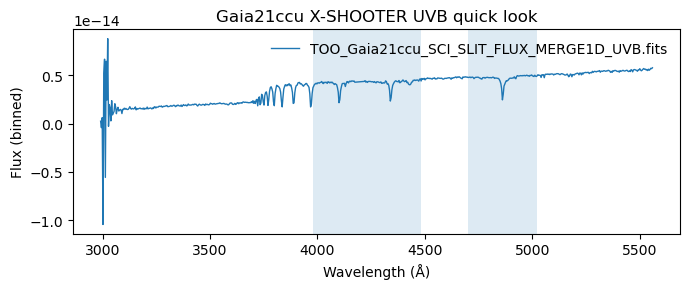

In [4]:
fit_windows = [
    ("Hdelta", 3980.0, 4220.0),
    ("Hgamma", 4220.0, 4480.0),
    ("Hbeta", 4700.0, 5020.0),
]

fig, ax = plot_binned_spectra(
    spectra=[seg0],
    nbins=700,
    title="Gaia21ccu X-SHOOTER UVB quick look",
    highlight_regions=[(w0, w1) for _, w0, w1 in fit_windows],
)
plt.show()


## 5. Choose the wavelength windows

For this example we focus on three broad hydrogen lines in the UVB arm: Hdelta, Hgamma, and Hbeta.

Each fit window will later be given a small padding so the forward model has a little extra support on both sides.


In [5]:
wmin = 3980.0
wmax = 5500.0
window_pad = 5.0

seg_clip = seg0.window(
    wmin=wmin,
    wmax=wmax,
    clip_left=0.0,
    clip_right=0.0,
    name_suffix="fitwin",
)

segments = make_padded_window_segments(
    seg_clip,
    fit_windows,
    pad=window_pad,
)

for seg_i, (label, _w0, _w1) in zip(segments, fit_windows):
    seg_i.name = label

print("Clipped segment:")
print(" name       :", seg_clip.name)
print(" pixels     :", len(seg_clip.wave))
print(" wave range :", float(np.min(seg_clip.wave)), float(np.max(seg_clip.wave)))

print("\nPer-window segments:")
for s in segments:
    print(
        f" {s.name:>6s} : "
        f"pixels={len(s.wave):4d}  "
        f"support=[{float(np.min(s.wave)):.1f}, {float(np.max(s.wave)):.1f}] Å  "
        f"fit_pixels={int(np.sum(s.mask))}"
    )


Clipped segment:
 name       : TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits_fitwin
 pixels     : 7601
 wave range : 3980.0 5500.0

Per-window segments:
 Hdelta : pixels=1226  support=[3980.0, 4225.0] Å  fit_pixels=974
 Hgamma : pixels=1351  support=[4215.0, 4485.0] Å  fit_pixels=1298
  Hbeta : pixels=1651  support=[4695.0, 5025.0] Å  fit_pixels=1585


## 6. Exclude the very line centers

For a simple first fit, it is often useful to exclude a narrow region around the center of each Balmer line and fit mainly the wings.

Here we use a symmetric half-width of 6 Å around each line center.


In [6]:
from Spyctres.recipes import make_balmer_core_exclude_mask

# For the core_mask_halfwidth, try 6, 8, 10, 12 Angstrom as a robustness check. 
# Stable parameters across this range are more trustworthy than a single fit.
core_mask_halfwidth = 6.0
exclude_mask = make_balmer_core_exclude_mask(
    core_halfwidth=core_mask_halfwidth,
    wave_medium=segments[0].wave_medium,
)

used_masks_plot = [
    build_effective_fit_mask(seg, exclude_mask=exclude_mask)
    for seg in segments
]

print("Per-window used pixels:")
for seg_i, mask_i in zip(segments, used_masks_plot):
    print(f" {seg_i.name:>6s}: {int(np.sum(mask_i))} / {len(seg_i.wave)}")
print("\nTotal used pixels:", int(sum(np.sum(m) for m in used_masks_plot)))


Per-window used pixels:
 Hdelta: 916 / 1226
 Hgamma: 1238 / 1351
  Hbeta: 1525 / 1651

Total used pixels: 3679


## 7. Define the PHOENIX grid

We do not use the full installed PHOENIX library for this example. Instead we choose a smaller subgrid around the part of parameter space that looks reasonable for this spectrum.

This keeps the notebook faster and makes the fit easier to interpret.

For real work, start broad enough that the solution is not pinned to a grid edge, then refine.


In [7]:
phoenix_lib = PhoenixLibrary(phoenix_dir, verbose=True)

teff_avail, feh_avail, logg_avail = phoenix_lib.available_axes()
print("Installed Teff range :", float(np.min(teff_avail)), float(np.max(teff_avail)))
print("Installed [Fe/H] range:", float(np.min(feh_avail)), float(np.max(feh_avail)))
print("Installed logg range :", float(np.min(logg_avail)), float(np.max(logg_avail)))

teff_grid_fit = teff_avail[(teff_avail >= 9000.0) & (teff_avail <= 11600.0)]
feh_grid_fit = feh_avail[(feh_avail >= -2.0) & (feh_avail <= 0.0)]
logg_grid_fit = logg_avail[(logg_avail >= 2.0) & (logg_avail <= 4.5)]

print("\nTeff grid :", teff_grid_fit)
print("FeH grid  :", feh_grid_fit)
print("logg grid :", logg_grid_fit)


Installed Teff range : 2300.0 12000.0
Installed [Fe/H] range: -4.0 1.0
Installed logg range : 0.0 6.0

Teff grid : [ 9000.  9200.  9400.  9600.  9800. 10000. 10200. 10400. 10600. 10800.
 11000. 11200. 11400. 11600.]
FeH grid  : [-2.  -1.5 -1.  -0.5 -0. ]
logg grid : [2.  2.5 3.  3.5 4.  4.5]


## 8. Run the fit

The fit solves for:
- effective temperature `Teff`
- metallicity `[Fe/H]`
- surface gravity `logg`
- radial velocity `RV`

It also solves a low-order multiplicative continuum correction for each segment during the fit.


In [8]:
R = seg0.meta.get("resolution_R", None)
# For simplicity, this example does not apply an additional barycentric correction during
# the fit, even though the reader reports one in the metadata.
# We set rv_bary_kms = 0.0 because it keeps the example focused on spectral classification. 
# The fitted RV should therefore be read as an internal alignment parameter, 
# not a final barycentric radial velocity.
rv_bary_kms = 0.0
# For a barycentric RV-oriented run, use:
# rv_bary_kms = seg0.meta.get("barycorr_kms", 0.0)
p0 = (10000.0, -0.5, 3.0, -5.0)

print("R used            :", R)
print("rv_bary_kms used  :", rv_bary_kms)
print("Initial guess p0  :", p0)

result = fit_phoenix_full_spectrum(
    segments=segments,
    phoenix_lib=phoenix_lib,
    p0=p0,
    exclude_mask=exclude_mask,
    rv_bary_kms=rv_bary_kms,
    R=R,
    forward_model="native_interp",
    teff_grid=teff_grid_fit,
    feh_grid=feh_grid_fit,
    logg_grid=logg_grid_fit,
    cache_path="/tmp/spyctres_example_xshooter_cache.npz",
    verbose=1,
    max_nfev=300,
)

print("\nFit result summary:")
for key in ["teff", "feh", "logg", "rv_kms", "chi2", "dof", "chi2_red", "success", "message"]:
    print(f"{key:>8s} : {result[key]}")


R used            : 5400.0
rv_bary_kms used  : 0.0
Initial guess p0  : (10000.0, -0.5, 3.0, -5.0)
Loaded PHOENIX cache from /tmp/spyctres_example_xshooter_cache.npz
RV init grid best: -22.5
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.2926e+04                                    1.34e+04    
       1              2         1.1005e+04      1.92e+03       2.95e+02       3.33e+03    
       2              3         1.0752e+04      2.53e+02       5.63e+01       9.39e+02    
       3              4         1.0732e+04      1.95e+01       2.25e+02       1.97e+03    
       4              5         1.0722e+04      9.75e+00       9.46e+01       1.24e+03    
       5              6         1.0720e+04      2.04e+00       2.09e+02       5.55e+02    
       6              7         1.0719e+04      1.57e+00       4.89e+00       3.71e+02    
       7              8         1.0719e+04      2.99e-01       3.20e+01       2.37

## 9. Reconstruct and inspect the fitted model

This is the main diagnostic step. The plots show the data, the fitted model, and which pixels were actually used in the fit.


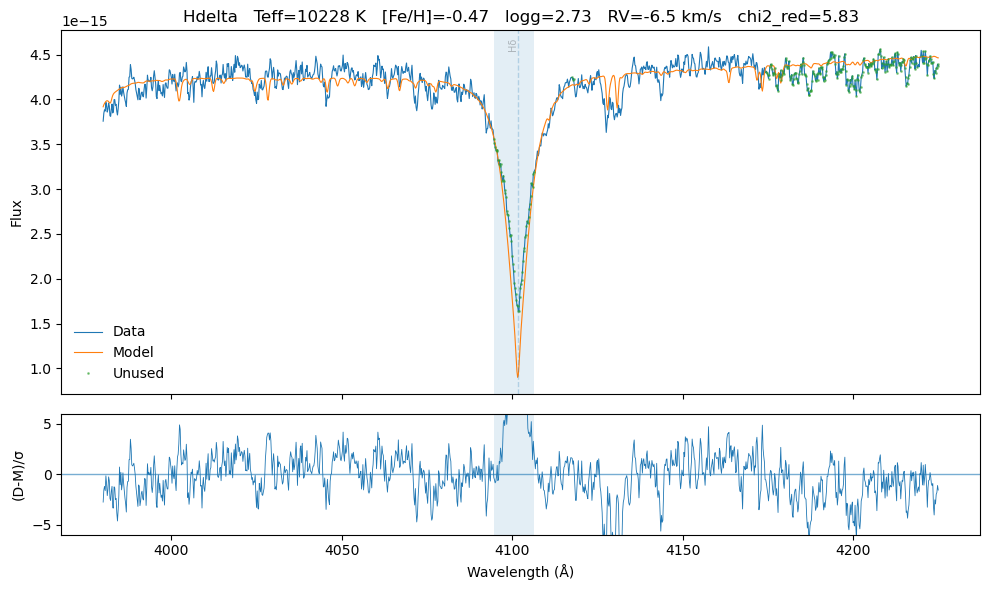

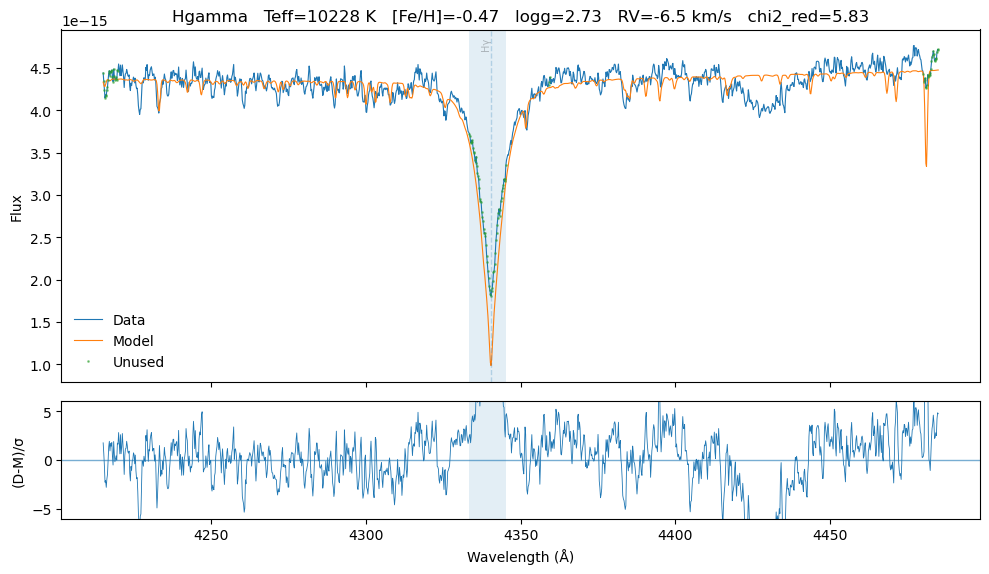

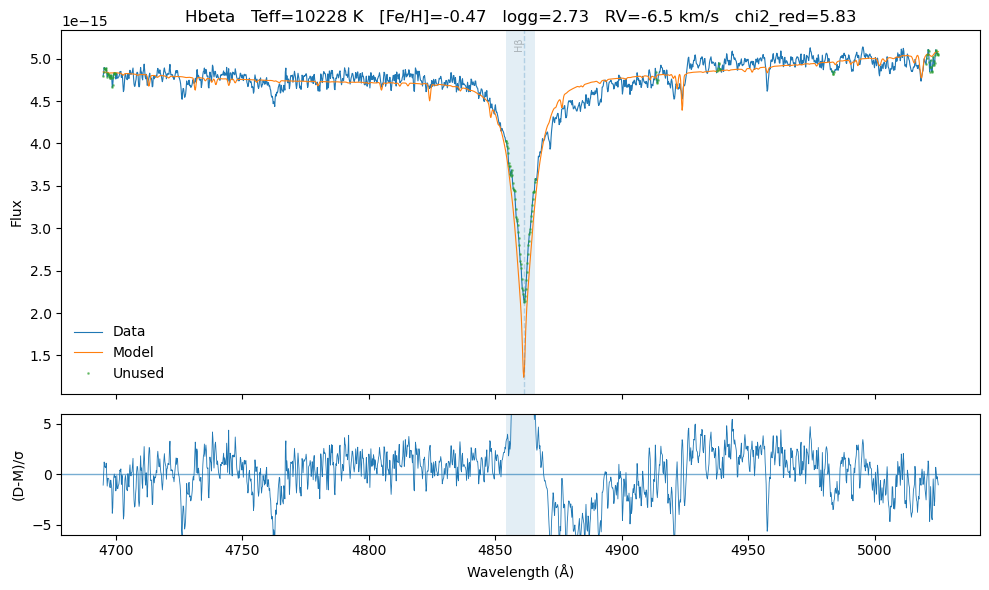

In [9]:
model_list, coeffs_list, used_masks, excluded_masks = reconstruct_phoenix_legendre_models_for_segments(
    segments=segments,
    phoenix_lib=phoenix_lib,
    fit_result=result,
    exclude_mask=exclude_mask,
    rv_bary_kms=rv_bary_kms,
    R=R,
    forward_model="native_interp",
)

for seg_i, model_i, used_i, excl_i in zip(segments, model_list, used_masks, excluded_masks):
    title = (
        f"{seg_i.name}   "
        f"Teff={result['teff']:.0f} K   "
        f"[Fe/H]={result['feh']:.2f}   "
        f"logg={result['logg']:.2f}   "
        f"RV={result['rv_kms']:.1f} km/s   "
        f"chi2_red={result['chi2_red']:.2f}"
    )
    fig, axes = plot_full_spectrum_fit(
        wave=seg_i.wave,
        flux=seg_i.flux,
        err=seg_i.err,
        model=model_i,
        used_mask=used_i,
        excluded_mask=excl_i,
        title=title,
        line_groups=["balmer"],
    )

    ax_top = axes[0]
    y_min = min(np.nanmin(seg_i.flux), np.nanmin(model_i))
    y_max = max(np.nanmax(seg_i.flux), np.nanmax(model_i))
    y_pad = 0.05 * (y_max - y_min)
    ax_top.set_ylim(y_min - y_pad, y_max + y_pad)
    plt.show()


The shaded region is excluded from the fit. A mismatch inside the shaded core should not be interpreted as a failed fit; the relevant comparison is mainly in the unshaded wings.

In [10]:
# Assess fit quality
print("chi2_red:", result["chi2_red"])
edge_flags = result.get("edge_flags", {})
print("edge flags:", edge_flags if edge_flags else "not reported")
print("line-window residuals should be inspected visually before adopting the classification.")

chi2_red: 5.832989681407738
edge flags: not reported
line-window residuals should be inspected visually before adopting the classification.


## 10. Summarize the result

This is a compact text summary that is easy to copy into notes.


In [11]:
fit_summary = {
    "Teff [K]": result["teff"],
    "[Fe/H]": result["feh"],
    "logg": result["logg"],
    "RV [km/s]": result["rv_kms"],
    "Reduced chi^2": result["chi2_red"],
}

print("Generic PHOENIX fit summary:")
for key, value in fit_summary.items():
    if isinstance(value, (int, float, np.floating)):
        print(f" {key:>15s} : {value:.3f}")
    else:
        print(f" {key:>15s} : {value}")

print("\nInterpretation:")
print(
    f"The spectrum is matched by a model with Teff {result['teff']:.0f} K, "
    f"[Fe/H] {result['feh']:.2f}, logg {result['logg']:.2f}, "
    f"and RV {result['rv_kms']:.1f} km/s."
)
print(
    "This should be read as a first model-based classification from a simple workflow, "
    "not as a final precision measurement."
)

Generic PHOENIX fit summary:
        Teff [K] : 10227.705
          [Fe/H] : -0.468
            logg : 2.730
       RV [km/s] : -6.549
   Reduced chi^2 : 5.833

Interpretation:
The spectrum is matched by a model with Teff 10228 K, [Fe/H] -0.47, logg 2.73, and RV -6.5 km/s.
This should be read as a first model-based classification from a simple workflow, not as a final precision measurement.


## 11. What to try next

A few natural follow-up tests are:
- revise the fitted wavelength windows
- try a different Balmer-core mask width
- test different PHOENIX subgrids
- inspect each line separately
- compare different continuum treatments
- revisit the assumed resolving power or wavelength handling if the residuals suggest a mismatch

For many real spectra, fitting is iterative: inspect the residuals, adjust the modeling choices, and fit again.
